# 📧 Prédiction de réponse à un email de prospection
## *Lead scoring — approche CRISP-DM*

---

Ce projet construit et compare **plusieurs modèles de machine learning** afin de prédire la
**probabilité qu'un lead réponde** à un email de prospection (`replied` = 0 / 1).

La démarche suit la méthodologie **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*),
le standard de référence pour les projets de data science, structuré en **6 phases** :

| Phase | Nom | Contenu |
|:---:|---|---|
| **1** | Compréhension du métier | Objectif business, critères de succès |
| **2** | Compréhension des données | Chargement, exploration (EDA) |
| **3** | Préparation des données | Feature engineering, préprocessing, split |
| **4** | Modélisation | Entraînement & validation croisée |
| **5** | Évaluation | Métriques, sélection, courbes de diagnostic |
| **6** | Déploiement | Prédiction, sauvegarde, maintenance |

---
> ⚠️ **Note sur ce jeu de données.** La cible `replied` a été partiellement générée par une règle
> (`segment = cold` ⇒ 0). Les variables `segment` et `score` dominent donc la prédiction *par
> construction*. Le pipeline est **complet et réutilisable tel quel sur de vraies données** ;
> gardez simplement en tête que, sur CE fichier, les scores reflètent surtout cette structure.


## ⚙️ Environnement technique

*Étape préliminaire — installation des bibliothèques et imports communs à toutes les phases.*


In [1]:
# XGBoost est généralement déjà présent sur Colab ; on l'installe au cas où.
!pip install -q xgboost scikit-learn pandas matplotlib seaborn joblib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# Style graphique homogène pour toute la présentation
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

print("XGBoost disponible :", HAS_XGB)


XGBoost disponible : True


# 1️⃣ Compréhension du métier
### *(Business Understanding)*

**🎯 Objectif métier**
Améliorer l'efficacité d'une campagne de prospection par email (*outbound*) en identifiant,
**avant l'envoi**, les leads les plus susceptibles de répondre — afin de concentrer les efforts
commerciaux là où ils rapportent le plus.

**🔬 Objectif data mining**
Construire un modèle de **classification binaire** qui estime la **probabilité de réponse**
(`replied` = 0/1) à partir des caractéristiques connues d'un lead : segment, score de
qualification, rôle, localisation, présence d'un email vérifié, présence d'insights, etc.

**✅ Critères de succès**
- Un **ROC-AUC** nettement supérieur au hasard (0.5) pour prioriser les leads de façon fiable.
- Des **probabilités bien calibrées**, exploitables directement par les équipes commerciales.
- Un **pipeline reproductible**, réutilisable sans modification sur de nouvelles données.

**⚠️ Contraintes connues**
La cible est en partie **synthétique** (règle déterministe sur `segment`). Les résultats
quantitatifs illustrent la démarche mais devront être revalidés sur des données réelles.


# 2️⃣ Compréhension des données
### *(Data Understanding)*

## 2.1 — Chargement des données

Uploadez `leads_dataset_827.csv` depuis votre ordinateur, ou ajustez le chemin si le fichier est
déjà présent sur Colab / Google Drive.


In [3]:
df = pd.read_csv("leads_data.csv")
print("Dimensions du jeu de données :", df.shape)
df.head()


Dimensions du jeu de données : (827, 13)


,id,company,role,location,source_url,notes,email,email_source,email_verified,score,segment,insights,replied
0,c4995965f0f2,Inferra Labs,VP Sales,"Dubai, UAE",https://techcrunch.com/inferra-raises-1723m-se...,Secured £172.3M (Series C) to accelerate growth,mariam.hassan@inferra.com,google,True,64,warm,"{""recent_news"": ""Inferra Labs expanded into a ...",1
1,351a2bad1188,Synth.ai,VP of Engineering,"New York, New York, United States",https://techfundingnews.com/synth-raises-61m-seed,Closed a £6.1M seed round in 2023,megan.thompson@synth.com,scraping,True,96,hot,"{""recent_news"": ""Synth.ai expanded into a new ...",0
2,ae16aa1b7f9d,Tendr.io,VP of Finance,Singapore,https://techfundingnews.com/tendr-raises-68m-seed,Announced $6.8M seed financing in 2024,mkoh@tendr.ai,pattern,False,95,hot,NaN,1
3,500590db5c61,Nordica Retail,VP Sales,"Turin, Italy",https://tech.eu/nordica-raises-48m-seed,Raised $4.8M in seed funding in 2023,sbianchi@nordica.io,google,True,96,hot,NaN,0
4,fec138f64e2d,Marqo,Chief Digital Officer,Singapore,https://theverge.com/marqo-raises-154m-seriesa,Raised $15.4M in Series A funding in 2025,kai.teo@marqo.sg,pattern,False,73,warm,"{""recent_news"": ""Marqo launched a new product ...",0


## 2.2 — Exploration rapide (EDA)

On vérifie la **structure** (types, valeurs manquantes), puis la **distribution de la cible** et sa relation avec les principales variables explicatives.

In [4]:
print("Types de données :")
print(df.dtypes, "\n")
print("Valeurs manquantes par colonne :")
print(df.isna().sum())


Types de données :
id                object
company           object
role              object
location          object
source_url        object
notes             object
email             object
email_source      object
email_verified      bool
score              int64
segment           object
insights          object
replied            int64
dtype: object 

Valeurs manquantes par colonne :
id                  0
company             0
role                0
location            0
source_url          0
notes               0
email              70
email_source       70
email_verified      0
score               0
segment             0
insights          167
replied             0
dtype: int64


Répartition de la cible :
replied
0    422
1    405
Name: count, dtype: int64

Proportion de réponses : 0.49


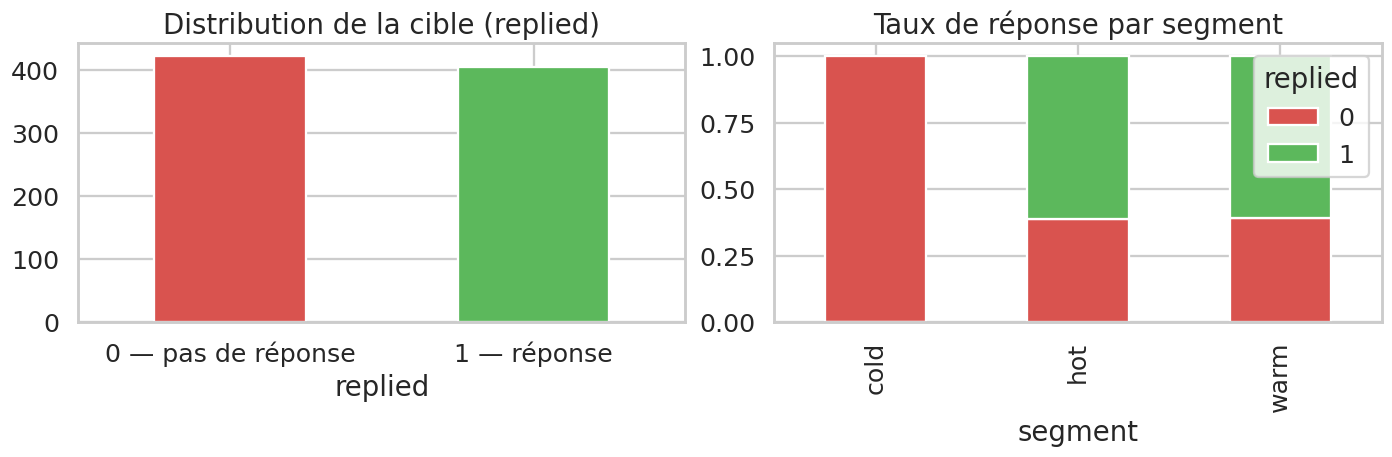

In [5]:
# Répartition de la cible et taux de réponse par segment
target = "replied"
print("Répartition de la cible :")
print(df[target].value_counts())
print("\nProportion de réponses :", round(df[target].mean(), 3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
df[target].value_counts().sort_index().plot(kind="bar", ax=ax[0],
        color=["#d9534f", "#5cb85c"])
ax[0].set_title("Distribution de la cible (replied)")
ax[0].set_xticklabels(["0 — pas de réponse", "1 — réponse"], rotation=0)

pd.crosstab(df["segment"], df[target], normalize="index").plot(
        kind="bar", stacked=True, ax=ax[1], color=["#d9534f", "#5cb85c"])
ax[1].set_title("Taux de réponse par segment")
ax[1].legend(["0", "1"], title="replied")
plt.tight_layout(); plt.show()


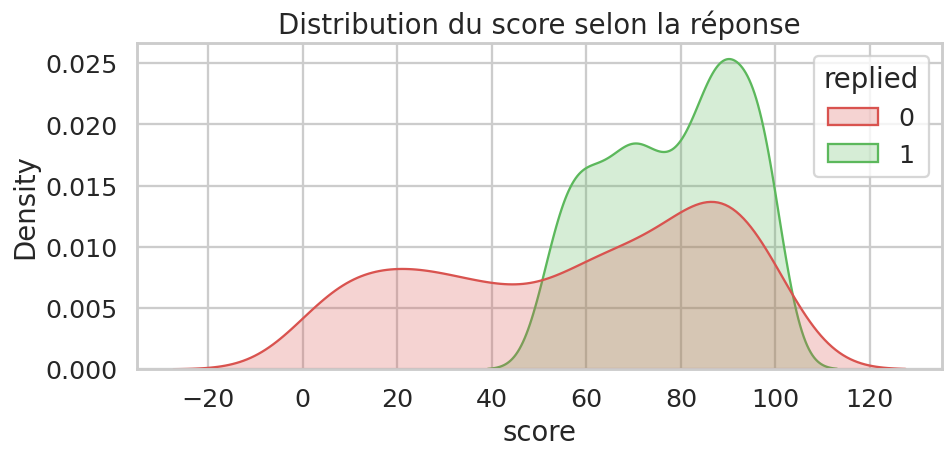

In [6]:
# Distribution du score selon la réponse
plt.figure(figsize=(9, 4.5))
sns.kdeplot(data=df, x="score", hue=target, fill=True, common_norm=False,
            palette=["#d9534f", "#5cb85c"])
plt.title("Distribution du score selon la réponse")
plt.tight_layout(); plt.show()


# 3️⃣ Préparation des données
### *(Data Preparation)*

## 3.1 — Feature engineering

On transforme les colonnes brutes en variables exploitables par les modèles :

| Variable créée | Origine | Type |
|---|---|---|
| `score` | tel quel | numérique |
| `email_verified` | booléen → 0/1 | binaire |
| `has_email` | email non vide | binaire |
| `has_insights` | insights non vide | binaire |
| `segment` | tel quel | catégoriel |
| `email_source` | manquants → "none" | catégoriel |
| `role_group` | regroupement du rôle (tech / sales / marketing / hr / finance) | catégoriel |
| `country` | pays extrait de `location` | catégoriel |

Les colonnes identifiantes ou en texte libre (`id`, `company`, `email`, `source_url`, `notes`,
`insights` brut) sont retirées.


In [7]:
CITY_TO_COUNTRY = {
    "berlin":"Germany","munich":"Germany","hamburg":"Germany","germany":"Germany",
    "singapore":"Singapore","london":"UK","manchester":"UK","cambridge":"UK",
    "basingstoke":"UK","uk":"UK","dubai":"UAE","abu dhabi":"UAE","uae":"UAE",
    "paris":"France","lyon":"France","toulouse":"France","france":"France",
    "milan":"Italy","rome":"Italy","turin":"Italy","bologna":"Italy","italy":"Italy",
    "madrid":"Spain","barcelona":"Spain","valencia":"Spain","spain":"Spain",
    "amsterdam":"Netherlands","rotterdam":"Netherlands","utrecht":"Netherlands","netherlands":"Netherlands",
    "stockholm":"Sweden","gothenburg":"Sweden","malmo":"Sweden","sweden":"Sweden",
    "tokyo":"Japan","osaka":"Japan","yokohama":"Japan","japan":"Japan",
    "bangalore":"India","mumbai":"India","delhi":"India","hyderabad":"India","india":"India",
    "sao paulo":"Brazil","rio de janeiro":"Brazil","belo horizonte":"Brazil","brazil":"Brazil",
    "toronto":"Canada","vancouver":"Canada","montreal":"Canada","canada":"Canada",
    "sydney":"Australia","melbourne":"Australia","brisbane":"Australia","australia":"Australia",
    "united states":"USA",
}

def get_country(loc):
    if pd.isna(loc): return "Unknown"
    parts = [p.strip() for p in str(loc).split(",")]
    last = parts[-1].lower()
    if last in CITY_TO_COUNTRY: return CITY_TO_COUNTRY[last]
    first = parts[0].lower()
    return CITY_TO_COUNTRY.get(first, parts[-1])

def role_group(role):
    r = str(role).lower()
    if any(k in r for k in ["cto","technology","engineering","head of ai","digital","data"]): return "tech"
    if any(k in r for k in ["sales"]): return "sales"
    if any(k in r for k in ["marketing","cmo","retail media"]): return "marketing"
    if any(k in r for k in ["hr","people","hrbp"]): return "hr"
    if any(k in r for k in ["finance","cfo"]): return "finance"
    return "other"

def build_features(data):
    d = pd.DataFrame()
    d["score"]          = data["score"]
    d["email_verified"] = data["email_verified"].astype(int)
    d["has_email"]      = data["email"].notna() & (data["email"].astype(str).str.strip() != "")
    d["has_email"]      = d["has_email"].astype(int)
    d["has_insights"]   = data["insights"].notna() & (data["insights"].astype(str).str.strip() != "")
    d["has_insights"]   = d["has_insights"].astype(int)
    d["segment"]        = data["segment"].fillna("unknown")
    d["email_source"]   = data["email_source"].fillna("none").replace("", "none")
    d["role_group"]     = data["role"].apply(role_group)
    d["country"]        = data["location"].apply(get_country)
    return d

X = build_features(df)
y = df["replied"].astype(int)
X.head()


,score,email_verified,has_email,has_insights,segment,email_source,role_group,country
0,64,1,1,1,warm,google,sales,UAE
1,96,1,1,1,hot,scraping,tech,USA
2,95,0,1,0,hot,pattern,finance,Singapore
3,96,1,1,0,hot,google,sales,Italy
4,73,0,1,1,warm,pattern,tech,Singapore


## 3.2 — Préprocessing (encodage & mise à l'échelle)

Le `ColumnTransformer` **standardise** la variable numérique, **laisse passer** les variables binaires et **encode en one-hot** les variables catégorielles. Il sera intégré dans chaque pipeline pour éviter toute fuite de données.

In [8]:
NUMERIC   = ["score"]
BINARY    = ["email_verified", "has_email", "has_insights"]
CATEGORIC = ["segment", "email_source", "role_group", "country"]

# OneHotEncoder compatible toutes versions de scikit-learn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("bin", "passthrough", BINARY),
    ("cat", ohe, CATEGORIC),
])
print("Variables numériques / binaires :", NUMERIC + BINARY)
print("Variables catégorielles        :", CATEGORIC)


Variables numériques / binaires : ['score', 'email_verified', 'has_email', 'has_insights']
Variables catégorielles        : ['segment', 'email_source', 'role_group', 'country']


## 3.3 — Découpage train / test (stratifié)

On met **20 %** des données de côté pour l'évaluation finale, en conservant la même proportion de réponses dans les deux ensembles (*stratification*).

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train :", X_train.shape, " | Test :", X_test.shape)
print("Taux de réponse — train :", round(y_train.mean(),3), "| test :", round(y_test.mean(),3))


Train : (661, 8)  | Test : (166, 8)
Taux de réponse — train : 0.49 | test : 0.488


# 4️⃣ Modélisation
### *(Modeling)*

## 4.1 — Définition des modèles

Cinq familles de modèles sont comparées, de la plus simple à la plus complexe :
**Régression logistique**, **Arbre de décision**, **Forêt aléatoire**, **Gradient Boosting**,
et **XGBoost** (si disponible). Chaque modèle est encapsulé dans une pipeline incluant le
préprocessing défini en phase 3.


In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
}
if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
        random_state=RANDOM_STATE)

# Chaque modèle est enveloppé dans une pipeline (préprocessing + modèle)
pipelines = {name: Pipeline([("prep", preprocess), ("clf", m)])
             for name, m in models.items()}
print("Modèles à comparer :", list(pipelines.keys()))


Modèles à comparer : ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## 4.2 — Comparaison par validation croisée

⚠️ **Point méthodologique important.** Le choix du meilleur modèle se fait ici sur la
**validation croisée (5 folds) du jeu d'entraînement**, et *non* sur le jeu de test.

**Pourquoi ?** La validation croisée moyenne la performance sur 5 découpages différents : elle
est donc **plus stable et plus fiable** qu'une mesure unique sur un petit jeu de test (~166 lignes),
où le classement peut varier au gré du hasard d'échantillonnage. Le jeu de test reste **intact**
jusqu'à la phase 5, pour fournir une estimation honnête de la performance réelle.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []
for name, pipe in pipelines.items():
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    f1  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    cv_results.append({"Modèle": name,
                       "ROC-AUC (CV)": auc.mean(), "±AUC": auc.std(),
                       "F1 (CV)": f1.mean()})
cv_df = pd.DataFrame(cv_results).sort_values("ROC-AUC (CV)", ascending=False).reset_index(drop=True)
cv_df.round(4)


,Modèle,ROC-AUC (CV),±AUC,F1 (CV)
0,Gradient Boosting,0.7046,0.0298,0.6618
1,Logistic Regression,0.7036,0.0293,0.6820
2,Decision Tree,0.6987,0.0335,0.7113
3,Random Forest,0.6983,0.0250,0.6674
4,XGBoost,0.6976,0.0357,0.6624


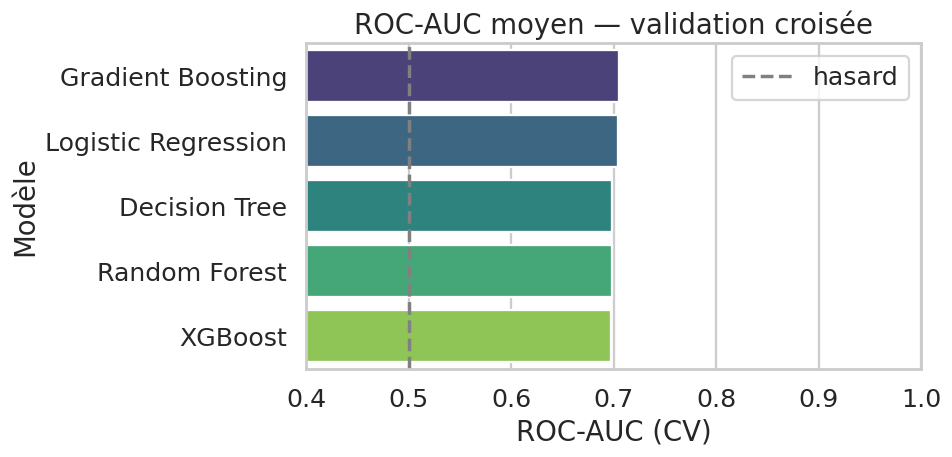

In [23]:
plt.figure(figsize=(9, 4.5))
sns.barplot(data=cv_df, y="Modèle", x="ROC-AUC (CV)", palette="viridis")
plt.xlim(0.4, 1.0)
plt.title("ROC-AUC moyen — validation croisée")
plt.axvline(0.5, ls="--", color="gray", label="hasard")
plt.legend(); plt.tight_layout(); plt.show()


# 5️⃣ Évaluation
### *(Evaluation)*

## 5.1 — Métriques sur le jeu de test

Chaque pipeline est ré-entraîné sur l'ensemble du train, puis évalué sur le jeu de test resté de
côté. On rapporte 6 métriques complémentaires : *Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC*.


In [13]:
def evaluate(pipe, X_te, y_te):
    proba = pipe.predict_proba(X_te)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return {
        "Accuracy":  accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall":    recall_score(y_te, pred, zero_division=0),
        "F1":        f1_score(y_te, pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_te, proba),
        "PR-AUC":    average_precision_score(y_te, proba),
    }

fitted, test_scores = {}, []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    s = evaluate(pipe, X_test, y_test); s["Modèle"] = name
    test_scores.append(s)

test_df = (pd.DataFrame(test_scores)
           .set_index("Modèle")
           .sort_values("ROC-AUC", ascending=False))
test_df.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Modèle,,,,,,
Decision Tree,0.7169,0.6349,0.9877,0.7729,0.7781,0.6950
Random Forest,0.6867,0.6559,0.7531,0.7011,0.7503,0.6795
Gradient Boosting,0.6747,0.6421,0.7531,0.6932,0.7468,0.6598
Logistic Regression,0.6687,0.6226,0.8148,0.7059,0.7415,0.6704
XGBoost,0.6446,0.6310,0.6543,0.6424,0.7251,0.6316


In [14]:
# Tableau de métriques coloré (plus lisible en présentation)
test_df.round(4).style.background_gradient(cmap="Greens", axis=0)\
    .format("{:.4f}").set_caption("Métriques sur le jeu de test")


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Modèle,,,,,,
Decision Tree,0.7169,0.6349,0.9877,0.7729,0.7781,0.6950
Random Forest,0.6867,0.6559,0.7531,0.7011,0.7503,0.6795
Gradient Boosting,0.6747,0.6421,0.7531,0.6932,0.7468,0.6598
Logistic Regression,0.6687,0.6226,0.8148,0.7059,0.7415,0.6704
XGBoost,0.6446,0.6310,0.6543,0.6424,0.7251,0.6316


## 5.2 — Sélection du meilleur modèle

Le modèle retenu est celui qui **maximise le ROC-AUC en validation croisée** (phase 4), pour les
raisons de robustesse évoquées plus haut. On affiche ensuite ses performances sur le jeu de test
et son rapport de classification détaillé.

> 💡 Le modèle en tête de la validation croisée n'est pas nécessairement premier sur le jeu de
> test : c'est **normal** et attendu, le test set étant petit. La sélection sur CV privilégie la
> **généralisation** plutôt que la performance sur un unique échantillon.


In [15]:
best_name = cv_df.iloc[0]["Modèle"]   # sélection sur la validation croisée
best_model = fitted[best_name]
print(f"🏆 Meilleur modèle (ROC-AUC validation croisée) : {best_name}\n")
print("Performance sur le jeu de test :")
print(test_df.loc[best_name].round(4))

print("\nRapport de classification :")
y_pred = (best_model.predict_proba(X_test)[:,1] >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=["pas de réponse","réponse"]))


🏆 Meilleur modèle (ROC-AUC validation croisée) : Gradient Boosting

Performance sur le jeu de test :
Accuracy     0.6747
Precision    0.6421
Recall       0.7531
F1           0.6932
ROC-AUC      0.7468
PR-AUC       0.6598
Name: Gradient Boosting, dtype: float64

Rapport de classification :
                precision    recall  f1-score   support

pas de réponse       0.72      0.60      0.65        85
       réponse       0.64      0.75      0.69        81

      accuracy                           0.67       166
     macro avg       0.68      0.68      0.67       166
  weighted avg       0.68      0.67      0.67       166



## 5.3 — Courbes de diagnostic

### 📈 5.3.1 — Courbes ROC (tous les modèles)

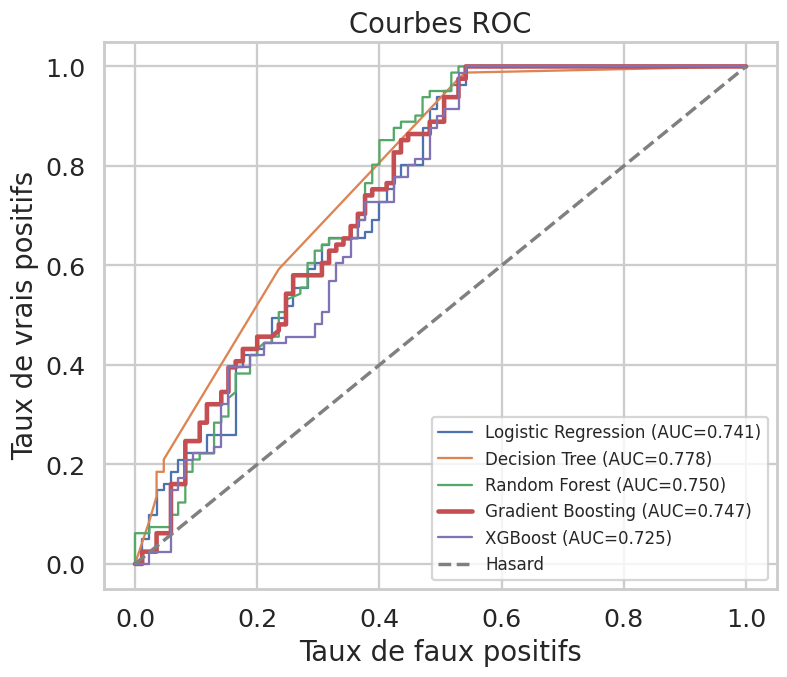

In [16]:
plt.figure(figsize=(7.5, 6.5))
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    lw = 3 if name == best_name else 1.5
    plt.plot(fpr, tpr, lw=lw, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"--",color="gray",label="Hasard")
plt.xlabel("Taux de faux positifs"); plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC"); plt.legend(loc="lower right", fontsize=11)
plt.tight_layout(); plt.show()


### 📉 5.3.2 — Courbes Precision-Recall (tous les modèles)

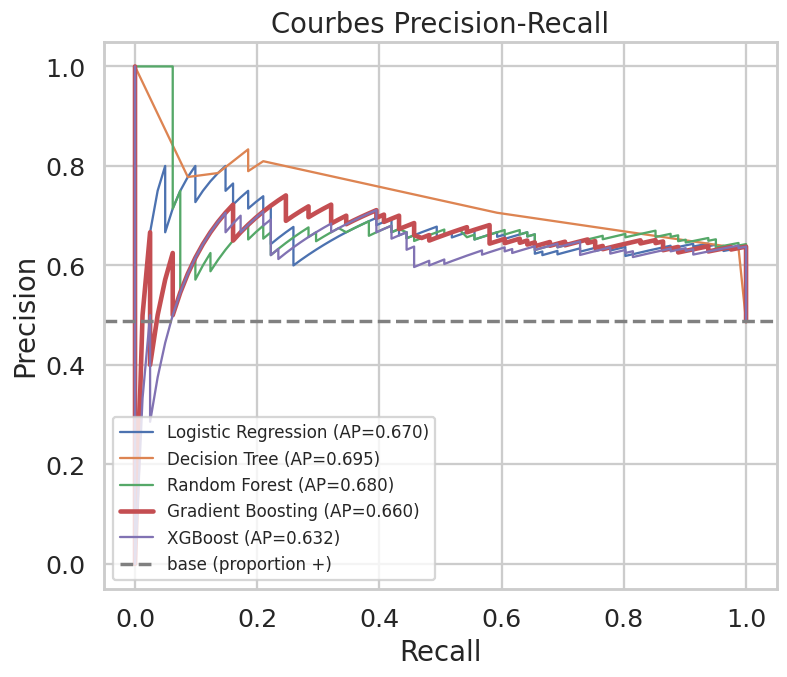

In [17]:
plt.figure(figsize=(7.5, 6.5))
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:,1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    lw = 3 if name == best_name else 1.5
    plt.plot(rec, prec, lw=lw, label=f"{name} (AP={ap:.3f})")
plt.axhline(y_test.mean(), ls="--", color="gray", label="base (proportion +)")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Courbes Precision-Recall"); plt.legend(loc="lower left", fontsize=11)
plt.tight_layout(); plt.show()


### 🔲 5.3.3 — Matrice de confusion (meilleur modèle)

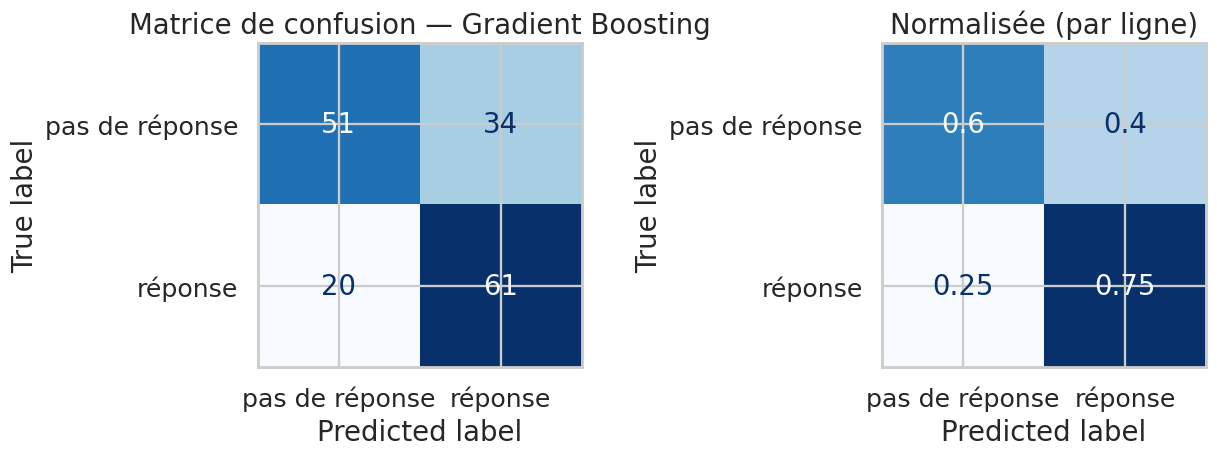

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0],
        display_labels=["pas de réponse","réponse"], colorbar=False, cmap="Blues")
ax[0].set_title(f"Matrice de confusion — {best_name}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[1], normalize="true",
        display_labels=["pas de réponse","réponse"], colorbar=False, cmap="Blues")
ax[1].set_title("Normalisée (par ligne)")
plt.tight_layout(); plt.show()


### 🎯 5.3.4 — Courbe de calibration (fiabilité des probabilités)

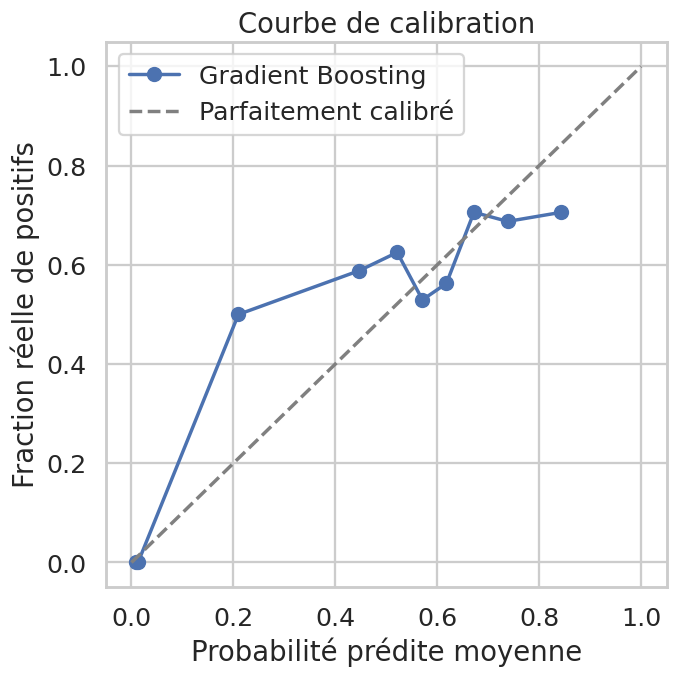

In [19]:
proba_best = best_model.predict_proba(X_test)[:,1]
frac_pos, mean_pred = calibration_curve(y_test, proba_best, n_bins=10, strategy="quantile")
plt.figure(figsize=(6.5, 6.5))
plt.plot(mean_pred, frac_pos, "o-", label=best_name)
plt.plot([0,1],[0,1],"--",color="gray",label="Parfaitement calibré")
plt.xlabel("Probabilité prédite moyenne"); plt.ylabel("Fraction réelle de positifs")
plt.title("Courbe de calibration"); plt.legend()
plt.tight_layout(); plt.show()


### 📊 5.3.5 — Importance des variables (meilleur modèle)

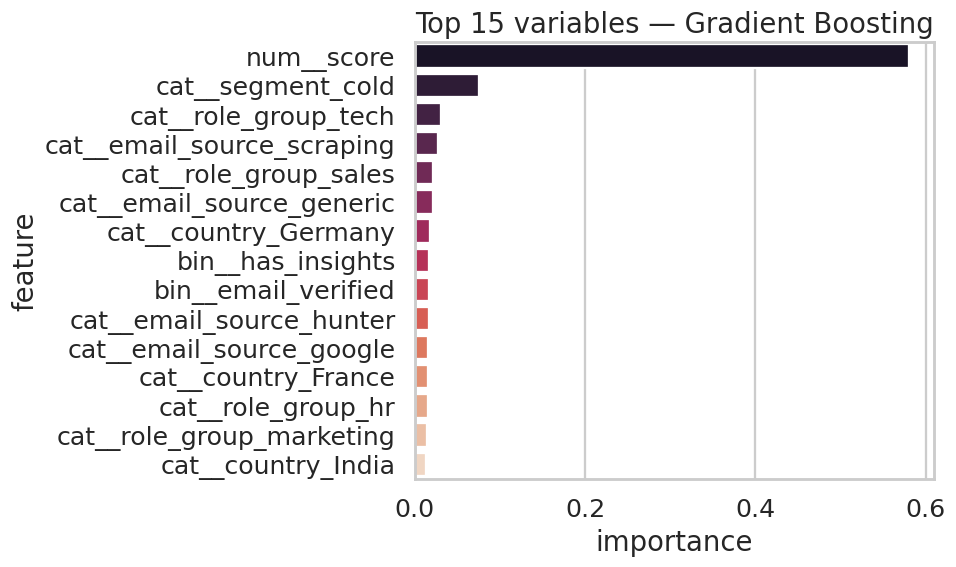

,feature,importance
0,num__score,0.580854
1,cat__segment_cold,0.074897
2,cat__role_group_tech,0.031147
3,cat__email_source_scraping,0.027251
4,cat__role_group_sales,0.021113
5,cat__email_source_generic,0.020914
6,cat__country_Germany,0.017530
7,bin__has_insights,0.017206
8,bin__email_verified,0.017139
9,cat__email_source_hunter,0.016068


In [20]:
def feature_names(pipe):
    return pipe.named_steps["prep"].get_feature_names_out()

clf = best_model.named_steps["clf"]
names = feature_names(best_model)
imp = None
if hasattr(clf, "feature_importances_"):
    imp = clf.feature_importances_
elif hasattr(clf, "coef_"):
    imp = np.abs(clf.coef_[0])

if imp is not None:
    fi = (pd.DataFrame({"feature": names, "importance": imp})
          .sort_values("importance", ascending=False).head(15))
    plt.figure(figsize=(9, 5.5))
    sns.barplot(data=fi, y="feature", x="importance", palette="rocket")
    plt.title(f"Top 15 variables — {best_name}")
    plt.tight_layout(); plt.show()
    display(fi.reset_index(drop=True))
else:
    print("Ce modèle n'expose pas d'importance de variables directe.")


# 6️⃣ Déploiement
### *(Deployment)*

## 6.1 — Prédire sur de nouveaux leads

La fonction ci-dessous applique **exactement le même feature engineering** qu'à l'entraînement,
puis renvoie la probabilité de réponse estimée. Elle s'utilise directement sur un DataFrame de
nouveaux leads ayant les mêmes colonnes brutes.


In [21]:
def predict_proba_leads(raw_df):
    """raw_df : DataFrame avec les MÊMES colonnes brutes que le dataset d'origine."""
    feats = build_features(raw_df)
    return best_model.predict_proba(feats)[:, 1]

# Exemple : 5 leads du test avec leur probabilité de réponse estimée
sample = df.loc[X_test.index].head(5).copy()
sample["proba_reponse"] = predict_proba_leads(sample)
cols = ["company","role","location","segment","email_verified","score","replied","proba_reponse"]
sample[cols]


,company,role,location,segment,email_verified,score,replied,proba_reponse
557,Tendr Bank,HR Manager,"Melbourne, Australia",hot,False,91,0,0.265354
710,Clearpay Capital,Head of Digital,Spain,hot,False,95,1,0.773550
550,Payflow Pay,VP of Finance,"Utrecht, Netherlands",hot,True,95,0,0.885331
678,Vesta Stores,VP Sales,Canada,warm,False,79,0,0.600950
314,Banca Bank,Head of Digital,"Cambridge, UK",cold,False,46,0,0.008320


## 6.2 — Sauvegarde du modèle

Le meilleur modèle (préprocessing inclus) est sérialisé dans un fichier `.joblib`, réutilisable en production sans ré-entraînement.

In [22]:
import joblib
joblib.dump(best_model, "best_lead_reply_model.joblib")
print(f"Modèle '{best_name}' sauvegardé dans best_lead_reply_model.joblib")

# Pour le re-télécharger depuis Colab :
try:
    from google.colab import files
    files.download("best_lead_reply_model.joblib")
except Exception:
    pass

# Rechargement ultérieur :
# import joblib; model = joblib.load("best_lead_reply_model.joblib")
# model.predict_proba(build_features(nouveaux_leads))[:,1]


Modèle 'Gradient Boosting' sauvegardé dans best_lead_reply_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6.3 — Synthèse & perspectives

**Ce qui a été livré**
- Un pipeline complet CRISP-DM, de la donnée brute à un modèle sauvegardé prêt à l'emploi.
- Une comparaison objective de 5 modèles, sélection sur validation croisée (robuste).
- Un jeu complet de diagnostics : ROC, Precision-Recall, matrice de confusion, calibration,
  importance des variables.

**Pistes d'amélioration**
- **Hyperparamètres** : `GridSearchCV` / `RandomizedSearchCV` / Optuna sur le modèle retenu.
- **Seuil de décision** : ajuster le seuil (0.5 par défaut) selon le coût réel d'un faux positif
  vs. faux négatif pour l'équipe commerciale.
- **Signal textuel** : exploiter `notes` et `insights` via TF-IDF ou embeddings.
- **Données réelles** : remplacer le CSV synthétique par de vrais leads — le pipeline fonctionne
  sans modification.
- **Suivi en production** : surveiller la dérive des données (*data drift*) et ré-entraîner
  périodiquement.

---
*Notebook structuré selon la méthodologie CRISP-DM.*
